In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# loading data files
customers = pd.read_csv("data/Customers.csv", encoding="latin1")
products = pd.read_csv("data/Products.csv", encoding="latin1")
sales = pd.read_csv("data/Sales.csv", encoding="latin1")
stores = pd.read_csv("data/Stores.csv", encoding="latin1")
 

print("data files loaded")

data files loaded


In [3]:

# # shape of data files

print(customers.shape)
print(products.shape)
print(sales.shape)
print(stores.shape)
 


(15266, 10)
(2517, 10)
(62884, 9)
(67, 5)


In [4]:
## data files info
print(customers.info())
print(products.info())
print(sales.info())
print(stores.info())

<class 'pandas.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CustomerKey  15266 non-null  int64
 1   Gender       15266 non-null  str  
 2   Name         15266 non-null  str  
 3   City         15266 non-null  str  
 4   State Code   15256 non-null  str  
 5   State        15266 non-null  str  
 6   Zip Code     15266 non-null  str  
 7   Country      15266 non-null  str  
 8   Continent    15266 non-null  str  
 9   Birthday     15266 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1.2 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProductKey      2517 non-null   int64
 1   Product Name    2517 non-null   str  
 2   Brand           2517 non-null   str  
 3   Color           2517 non-null   str  
 4   Unit Cost US

From the above information we can see in table
1. Customers

Birthday is string this must convert to datetime

State Code has 10 missing values

2. Products

Unit Cost USD and Unit Price USD are strings but should be numeric

3. Sales

Order Date and Delivery Date are strings need to be converted to datetime

Delivery Date has many missing values 

4. Stores

Square Meters has 1 missing value

Open Date is string need to convert to datetime

In [5]:
customers["Birthday"] = pd.to_datetime(customers["Birthday"])

products["Unit Cost USD"] = products["Unit Cost USD"].replace('[\$,]', '', regex=True).astype(float)
products["Unit Price USD"] = products["Unit Price USD"].replace('[\$,]', '', regex=True).astype(float)

sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Delivery Date"] = pd.to_datetime(sales["Delivery Date"])

stores["Open Date"] = pd.to_datetime(stores["Open Date"])

In [6]:
# checking missing  value in keycolumns
sales[["CustomerKey","ProductKey","StoreKey"]].isnull().sum()

CustomerKey    0
ProductKey     0
StoreKey       0
dtype: int64

In [7]:
# merging tables
data = (
    sales
    .merge(customers, on="CustomerKey", how="left")
    .merge(products, on="ProductKey", how="left")
    .merge(stores, on="StoreKey", how="left")
)

In [8]:
data.shape

(62884, 31)

In [9]:
data.info()
 

<class 'pandas.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Number    62884 non-null  int64         
 1   Line Item       62884 non-null  int64         
 2   Order Date      62884 non-null  datetime64[us]
 3   Delivery Date   13165 non-null  datetime64[us]
 4   CustomerKey     62884 non-null  int64         
 5   StoreKey        62884 non-null  int64         
 6   ProductKey      62884 non-null  int64         
 7   Quantity        62884 non-null  int64         
 8   Currency Code   62884 non-null  str           
 9   Gender          62884 non-null  str           
 10  Name            62884 non-null  str           
 11  City            62884 non-null  str           
 12  State Code      62854 non-null  str           
 13  State_x         62884 non-null  str           
 14  Zip Code        62884 non-null  str           
 15  Country_x    

In [10]:
#columns in data 
print(data.columns)

Index(['Order Number', 'Line Item', 'Order Date', 'Delivery Date',
       'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code',
       'Gender', 'Name', 'City', 'State Code', 'State_x', 'Zip Code',
       'Country_x', 'Continent', 'Birthday', 'Product Name', 'Brand', 'Color',
       'Unit Cost USD', 'Unit Price USD', 'SubcategoryKey', 'Subcategory',
       'CategoryKey', 'Category', 'Country_y', 'State_y', 'Square Meters',
       'Open Date'],
      dtype='str')


In [11]:
#handeling overlapping columns
data = data.rename(columns={
    "Country_x": "CustomerCountry",
    "Country_y": "StoreCountry",
    "State_x": "CustomerState",
    "State_y": "StoreState"
})

In [12]:
# checking duplicates
print(data.duplicated().sum())

0


no duplicates present

In [13]:
#checking null values
data.isnull().sum()

Order Number           0
Line Item              0
Order Date             0
Delivery Date      49719
CustomerKey            0
StoreKey               0
ProductKey             0
Quantity               0
Currency Code          0
Gender                 0
Name                   0
City                   0
State Code            30
CustomerState          0
Zip Code               0
CustomerCountry        0
Continent              0
Birthday               0
Product Name           0
Brand                  0
Color                  0
Unit Cost USD          0
Unit Price USD         0
SubcategoryKey         0
Subcategory            0
CategoryKey            0
Category               0
StoreCountry           0
StoreState             0
Square Meters      13165
Open Date              0
dtype: int64

In [14]:
data.isnull().mean() * 100

Order Number        0.000000
Line Item           0.000000
Order Date          0.000000
Delivery Date      79.064627
CustomerKey         0.000000
StoreKey            0.000000
ProductKey          0.000000
Quantity            0.000000
Currency Code       0.000000
Gender              0.000000
Name                0.000000
City                0.000000
State Code          0.047707
CustomerState       0.000000
Zip Code            0.000000
CustomerCountry     0.000000
Continent           0.000000
Birthday            0.000000
Product Name        0.000000
Brand               0.000000
Color               0.000000
Unit Cost USD       0.000000
Unit Price USD      0.000000
SubcategoryKey      0.000000
Subcategory         0.000000
CategoryKey         0.000000
Category            0.000000
StoreCountry        0.000000
StoreState          0.000000
Square Meters      20.935373
Open Date           0.000000
dtype: float64

| Column        | Missing | %  
| ------------- | ------- | ------ | 
| Delivery Date | 49,719  | ~79%   | 
| State Code    | 30      | ~0.05% | 
| Square Meters | 13,165  | ~21%   | 


In [15]:
# Handeling missing values
data["State Code"] = data["State Code"].fillna("Unknown")
data["Square Meters"] = data["Square Meters"].fillna(data["Square Meters"].median())

Delivery date is missing because the order may not have been delivered yet.

Imputing a date would introduce false information.

In [16]:
# rechecking null values

data.isnull().sum()

Order Number           0
Line Item              0
Order Date             0
Delivery Date      49719
CustomerKey            0
StoreKey               0
ProductKey             0
Quantity               0
Currency Code          0
Gender                 0
Name                   0
City                   0
State Code             0
CustomerState          0
Zip Code               0
CustomerCountry        0
Continent              0
Birthday               0
Product Name           0
Brand                  0
Color                  0
Unit Cost USD          0
Unit Price USD         0
SubcategoryKey         0
Subcategory            0
CategoryKey            0
Category               0
StoreCountry           0
StoreState             0
Square Meters          0
Open Date              0
dtype: int64

In [17]:
# feature engineering
data["Revenue"] = data["Quantity"] * data["Unit Price USD"]
data["Profit"] = (data["Unit Price USD"] - data["Unit Cost USD"]) * data["Quantity"]
data["Profit_Margin"] = (data["Unit Price USD"] - data["Unit Cost USD"]) / data["Unit Price USD"]
data["Year"] = data["Order Date"].dt.year
data["Month"] = data["Order Date"].dt.month
data["MonthName"] = data["Order Date"].dt.month_name()

# Product Performance

In [18]:
top_products = data.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)


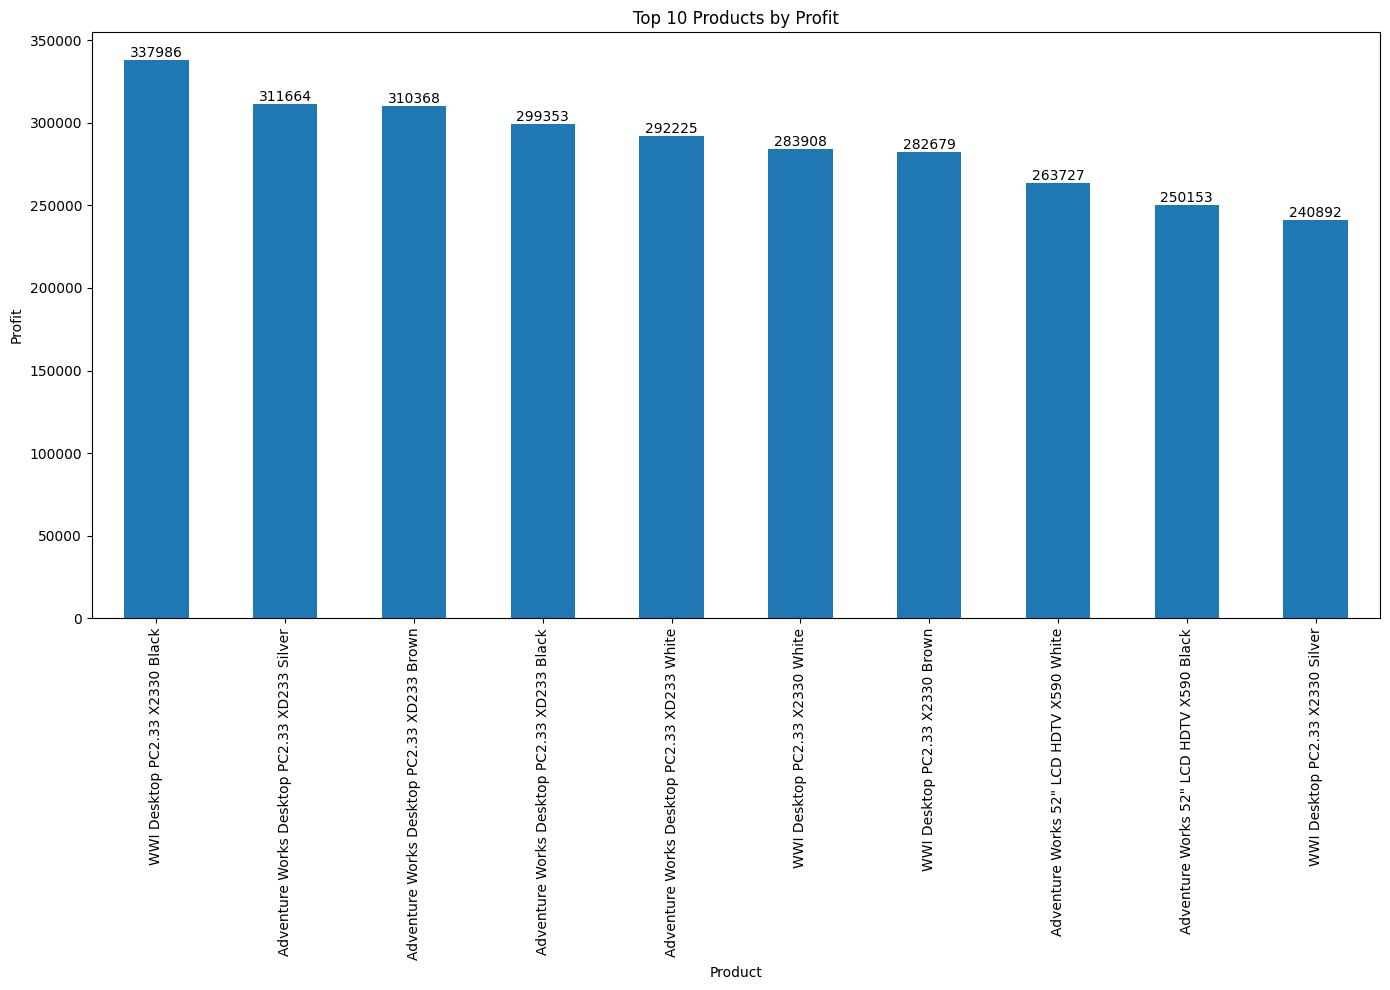

In [19]:
ax = top_products.plot(
    kind="bar",
    figsize=(14,10)
)

plt.title("Top 10 Products by Profit")
plt.ylabel("Profit")
plt.xlabel("Product")
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

# Category Performance

In [20]:
category_perf = data.groupby("Category").agg({
    "Revenue":"sum",
    "Profit":"sum"
})

category_perf["Profit_Margin"] = category_perf["Profit"] / category_perf["Revenue"]
category_perf = category_perf.sort_values("Revenue", ascending=False)

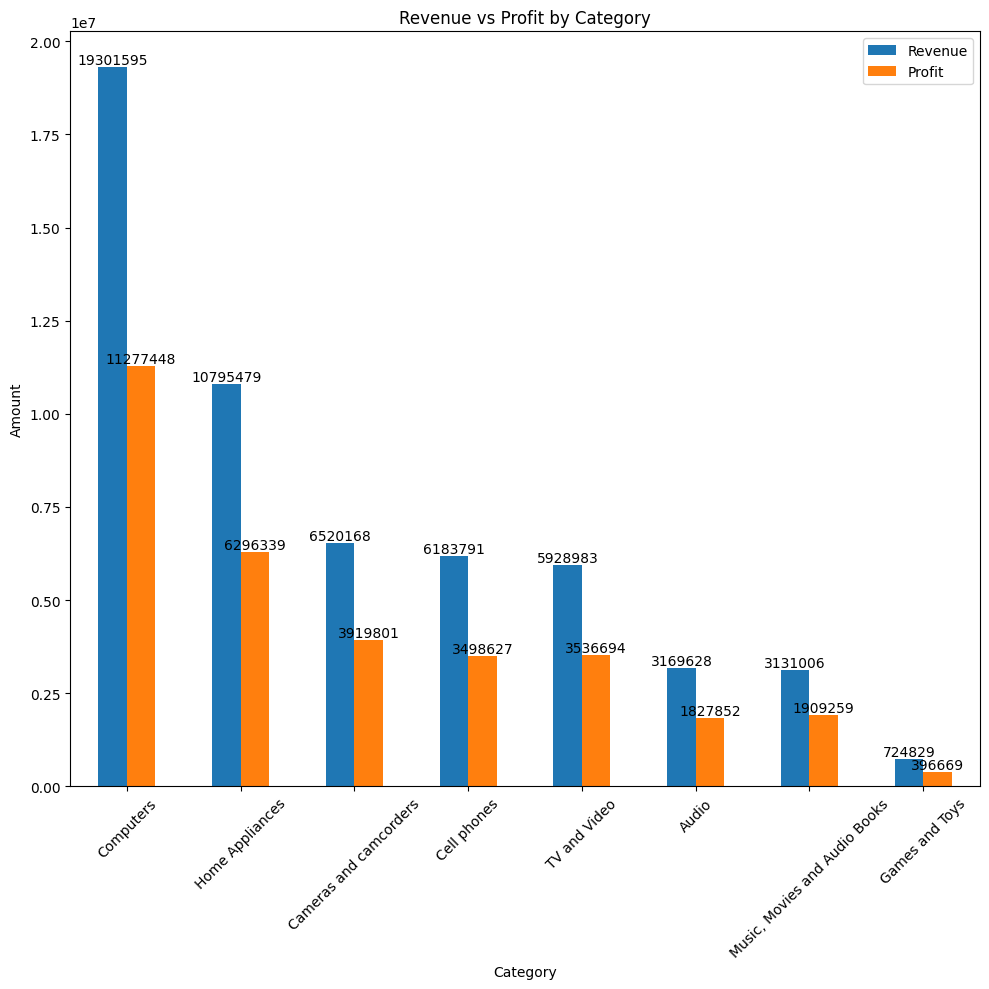

In [21]:

ax = category_perf[["Revenue","Profit"]].plot(
    kind="bar",
    figsize=(10,10)
)

plt.title("Revenue vs Profit by Category")
plt.ylabel("Amount")
plt.xlabel("Category")
plt.xticks(rotation=45)


for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

# Store performance

In [22]:
data["StoreName"] = data["City"] + ", " + data["StoreState"]

In [23]:
store_perf = data.groupby("StoreName")[["Revenue","Profit"]].sum() \
                 .sort_values("Revenue", ascending=False).head(10)

store_perf

,Revenue,Profit
StoreName,,
"Toronto, Newfoundland and Labrador",175215.27,102959.68
"Toronto, Northwest Territories",158394.10,90606.67
"Toronto, Online",146615.92,85127.09
"Las Vegas, Nevada",127615.12,76681.63
"Toronto, Nunavut",120412.58,69892.79
"New York, Online",116090.36,66997.41
"Washington, Washington DC",114995.58,70345.66
"Montreal, Northwest Territories",101462.11,57518.76
"Portland, Online",98428.59,60415.18


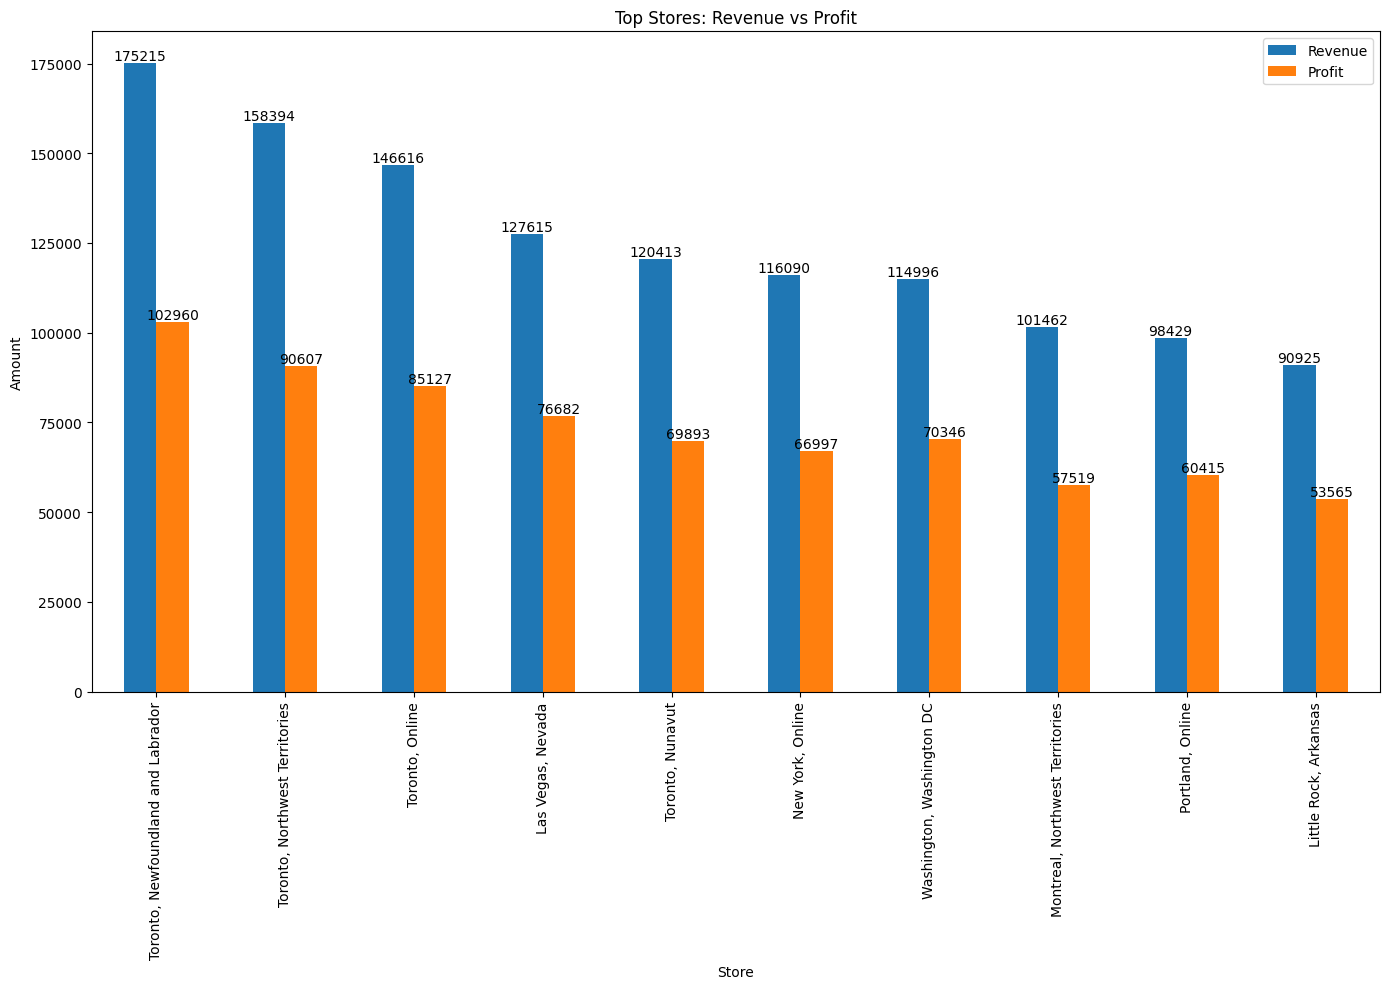

In [24]:
ax = store_perf.plot(
    kind="bar",
    figsize=(14,10)
)

plt.title("Top Stores: Revenue vs Profit")
plt.ylabel("Amount")
plt.xlabel("Store")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

# Geographic sales

In [25]:

geographic_sales=data.groupby("StoreCountry")["Revenue"].sum().sort_values(ascending=False)
geographic_sales

StoreCountry
United States     23764425.86
Online            11404324.63
United Kingdom     5749769.78
Germany            4246279.22
Canada             3611561.79
Australia          2099141.07
Italy              2059086.81
Netherlands        1591344.48
France             1229545.95
Name: Revenue, dtype: float64

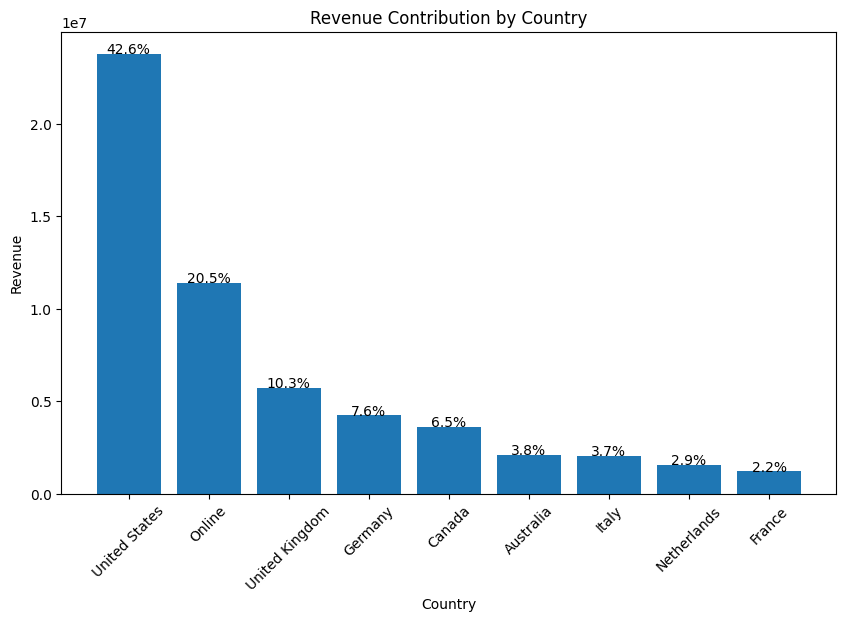

In [26]:
plt.figure(figsize=(10,6))

bars = plt.bar(geographic_sales.index, geographic_sales.values)

total = geographic_sales.sum()

for bar in bars:
    height = bar.get_height()
    pct = height / total * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center'
    )

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Revenue Contribution by Country")

plt.show()

# Customer demographics

In [27]:
gender_sales =data.groupby("Gender")["Revenue"].sum()
gender_sales 

Gender
Female    27420624.99
Male      28334854.60
Name: Revenue, dtype: float64

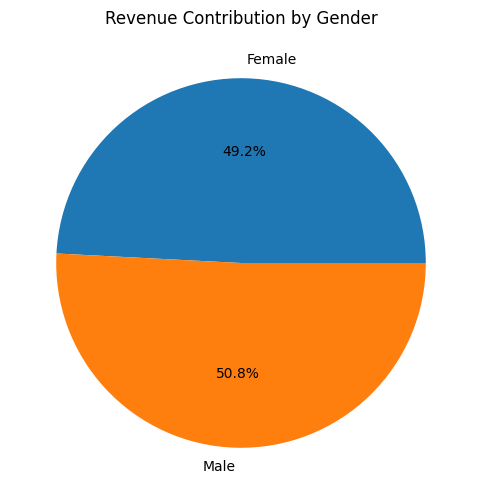

In [28]:
plt.figure(figsize=(6,6))
plt.pie(gender_sales.values,
        labels=gender_sales.index,
        autopct='%1.1f%%')

plt.title("Revenue Contribution by Gender")
plt.show()

# AGE Distribution

In [29]:
data["Age"] = pd.Timestamp.now().year - data["Birthday"].dt.year

In [30]:
bins = [0,18,25,35,45,55,65,100]
labels = ["<18","18-25","26-35","36-45","46-55","56-65","65+"]

data["Age_Group"] = pd.cut(data["Age"], bins=bins, labels=labels)

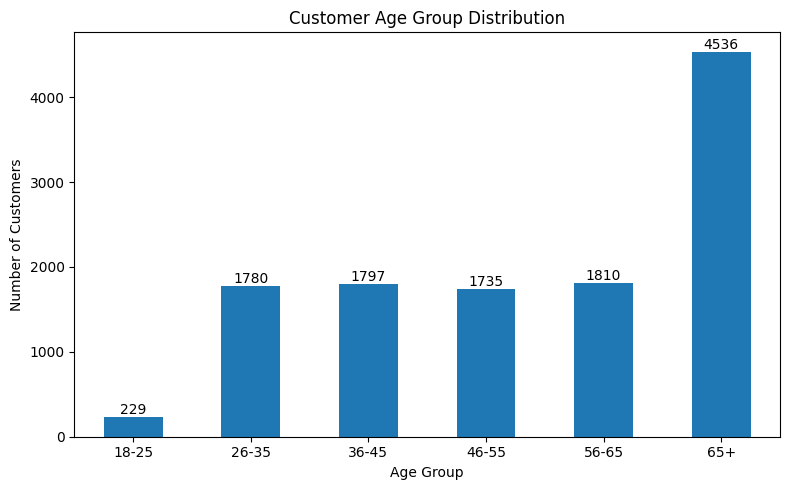

In [31]:
age_distribution = data.groupby("Age_Group")["CustomerKey"].nunique()

ax = age_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Age Group Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Age Group")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Revenue and Profit per meter square

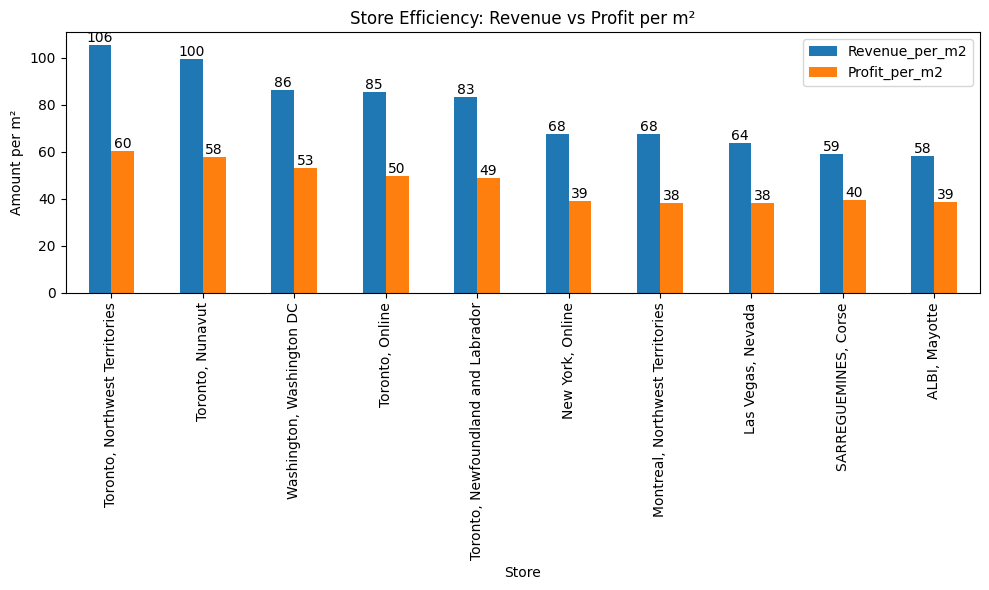

In [35]:
store_metrics = data.groupby("StoreName").agg({
    "Revenue": "sum",
    "Profit": "sum",
    "Square Meters": "first"
})

store_metrics["Revenue_per_m2"] = store_metrics["Revenue"] / store_metrics["Square Meters"]
store_metrics["Profit_per_m2"] = store_metrics["Profit"] / store_metrics["Square Meters"]

top_stores = store_metrics.sort_values("Revenue_per_m2", ascending=False).head(10)

ax = top_stores[["Revenue_per_m2","Profit_per_m2"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Store Efficiency: Revenue vs Profit per m²")
plt.ylabel("Amount per m²")
plt.xlabel("Store")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Time-series trend

In [33]:
monthly_sales =data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Revenue"].sum()
monthly_sales 

Order Date
2016-01-31    649918.78
2016-02-29    891098.30
2016-03-31    338407.36
2016-04-30    110591.63
2016-05-31    595986.18
                ...    
2020-10-31    245647.59
2020-11-30    256701.02
2020-12-31    651526.44
2021-01-31    513021.58
2021-02-28    526266.90
Freq: ME, Name: Revenue, Length: 62, dtype: float64

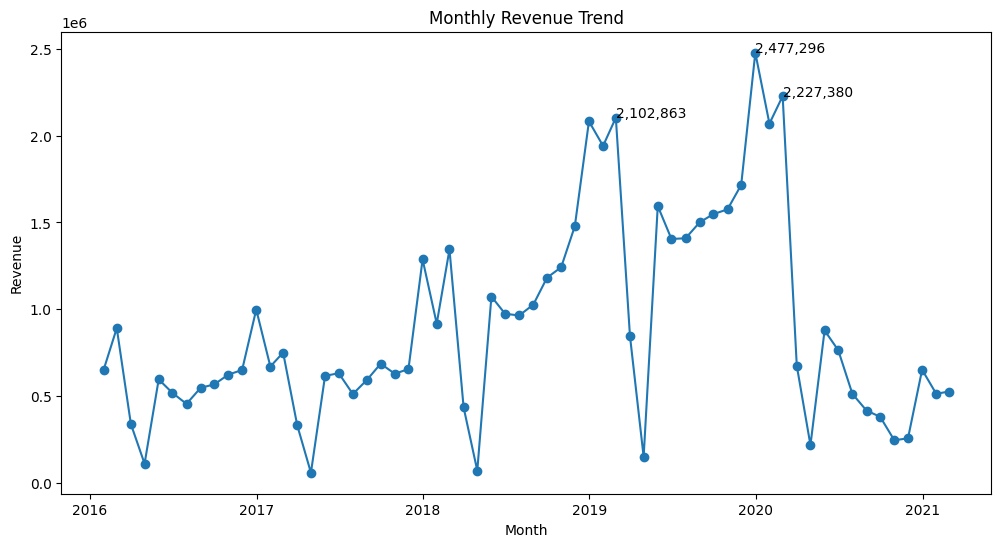

In [34]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
top_months = monthly_sales.nlargest(3)

for date, value in top_months.items():
    plt.text(date, value, f'{value:,.0f}')

plt.show()

# Business Performance Insights



## 1. Computers Dominate the Business

The **Computers** category generated **$19.30M in revenue** and **$11.28M in profit**, making it the company's primary revenue and profitability driver. This category alone produces **~1.8× more revenue** than the second-largest category (Home Appliances at $10.80M).

> **Implication:** Computers should remain the core strategic focus for inventory, marketing, and promotions.

---

## 2. Desktop PCs Drive Product-Level Profitability

The **WWI Desktop PC2.33 X2330 Black** is the most profitable product with **$337,986 profit**, and **8 of the top 10** profit-generating products are desktop computers.

> **Implication:** Desktop PCs represent the highest-value product line, suggesting strong demand and margin performance.

---

## 3. Revenue Is Highly Concentrated in the U.S. and Online Channels

The **United States** contributes **42.6%** of total revenue, while **online sales** account for **20.5%**, meaning **63.1%** of company revenue comes from these two channels alone.

> **Implication:** The business has high geographic and channel concentration risk, making diversification important for long-term stability.

---

## 4. Online Stores Are the Most Operationally Efficient

The **Online store** generates:
- **$6,650 revenue per m²**
- **$3,891 profit per m²**

This significantly outperforms physical stores such as Wyoming ($1,454 revenue per m²).

> **Implication:** Digital channels deliver superior space efficiency and scalability, making them critical for future growth.

---

## 5. The Customer Base Is Dominated by Older Consumers

| Age Group | Customers |
|-----------|-----------|
| 65+       | 4,536     |
| 18–25     | 229       |

The **65+ age group** accounts for more than **double** any other age segment.

> **Implication:** The company's products appeal strongly to older demographics, indicating potential opportunities to target younger consumers through marketing or product adjustments.

---

## 6. Sales Growth Peaked in Early 2020

Monthly revenue reached its highest point at **$2.48M**, followed by a noticeable decline later in 2020.

> **Implication:** The business experienced rapid growth followed by a significant drop, suggesting possible external factors affecting demand.

---

## Summarizing

The company's revenue is driven by **computer hardware sales**, concentrated in the **U.S. market**, and strongly supported by **online channels**.

While product profitability and digital efficiency are strong, the customer base is skewed toward **older demographics**, and revenue concentration indicates opportunities for:

- Market diversification
- Younger customer acquisition